# Extract polygons of Spanish cities

When extracting the polygons for european cities with >100k citizens from OpenStreetMap (see notebook `check_polygons.ipynb`), some polygons were found to be too big. 

This was the case for 43 Spanish cities.

Spain's are:
- Autonomous Communities
- Province
- Comarca
- Municipality

## Setup

In [1]:
import requests
from shapely import Polygon, MultiPolygon
from shapely.geometry import shape
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as cx
import textwrap # for long titles
import os
from shapely.ops import unary_union
import pandas as pd
import osmnx as ox

## Import "unaccepted" Spanish cities

In [4]:
european_100000pop = pd.read_excel(
    '../cities/development/european_100000pop_comments.xlsx',
    sheet_name = 'Comments',
    usecols = "A:C,E:F,H"
    ).query("accepted == 0 & country_en == 'Spain'").drop(columns = ['accepted']).sort_values(by=['name_en', 'country_en']).reset_index(drop=True).set_index('name_en')
european_100000pop

,country_en,nominatim_query,alpha-2,population
name_en,,,,
A Coruña,Spain,A Coruña,ES,245541
Albacete,Spain,Albacete,ES,172806
Algeciras,Spain,Algeciras,ES,123435
Alicante/Alacant,Spain,Alicante/Alacant,ES,338768
Badajoz,Spain,Badajoz,ES,151048
Barakaldo,Spain,Barakaldo,ES,100847
Bilbao,Spain,Bilbao,ES,345749
Burgos,Spain,Burgos,ES,174154
Cartagena,Spain,Cartagena,ES,215826


In [9]:
city = "Vitoria-Gasteiz"

osm = ox.geocoder.geocode_to_gdf(european_100000pop.loc[city,'nominatim_query'])

municipio = spain.query(f"NAMEUNIT.str.contains('{city}', case=False, na=False)")

osm_poly = osm.geometry.iloc[0]
tags = {
    'boundary': 'administrative',
    'admin_level': '10'  
}
subdivisions = ox.features_from_polygon(osm_poly, tags=tags).query("admin_level == '10'")
clipped_subdivisions = gpd.clip(subdivisions, osm_poly)
clipped_subdivisions = clipped_subdivisions[
    clipped_subdivisions.geometry.type.isin(['Polygon', 'MultiPolygon'])
]
display(subdivisions) 
display(clipped_subdivisions)

geometry  \
element  id                                                            
relation 10312620  MULTIPOLYGON (((-2.66371 42.7766, -2.6635 42.7...   
         11007880  POLYGON ((-2.57894 42.84429, -2.57839 42.84501...   

                         boundary admin_level highway  \
element  id                                             
relation 10312620  administrative          10     NaN   
         11007880  administrative          10     NaN   

                                      name                  name:es  \
element  id                                                           
relation 10312620  Gasteizko mendi garaiak  Montes Altos de Vitoria   
         11007880   Comunidad de Estíbaliz                      NaN   

                                   name:eu official_name border_type name:ar  \
element  id                                                                    
relation 10312620  Gasteizko mendi garaiak           NaN         NaN     NaN   
         11007880                      NaN           NaN         NaN     NaN   

                   ...  fax phone alt_name:fr old_name:es old_name:eu  \
element  id        ...                                                  
relation 10312620  ...  NaN   NaN         NaN         NaN         NaN   
         11007880  ...  NaN   NaN         NaN         NaN         NaN   

                  alt_name:es alt_name:eu short_name:es short_name:eu  \
element  id                                                             
relation 10312620         NaN         NaN           NaN           NaN   
         11007880         NaN         NaN           NaN           NaN   

                  wikimedia_commons  
element  id                          
relation 10312620               NaN  
         11007880               NaN  

[2 rows x 125 columns]

geometry  \
element  id                                                            
relation 10312620  MULTIPOLYGON (((-2.6635 42.77737, -2.66312 42....   
         11007880  POLYGON ((-2.57839 42.84501, -2.57729 42.84571...   

                         boundary admin_level highway  \
element  id                                             
relation 10312620  administrative          10     NaN   
         11007880  administrative          10     NaN   

                                      name                  name:es  \
element  id                                                           
relation 10312620  Gasteizko mendi garaiak  Montes Altos de Vitoria   
         11007880   Comunidad de Estíbaliz                      NaN   

                                   name:eu official_name border_type name:ar  \
element  id                                                                    
relation 10312620  Gasteizko mendi garaiak           NaN         NaN     NaN   
         11007880                      NaN           NaN         NaN     NaN   

                   ...  fax phone alt_name:fr old_name:es old_name:eu  \
element  id        ...                                                  
relation 10312620  ...  NaN   NaN         NaN         NaN         NaN   
         11007880  ...  NaN   NaN         NaN         NaN         NaN   

                  alt_name:es alt_name:eu short_name:es short_name:eu  \
element  id                                                             
relation 10312620         NaN         NaN           NaN           NaN   
         11007880         NaN         NaN           NaN           NaN   

                  wikimedia_commons  
element  id                          
relation 10312620               NaN  
         11007880               NaN  

[2 rows x 125 columns]

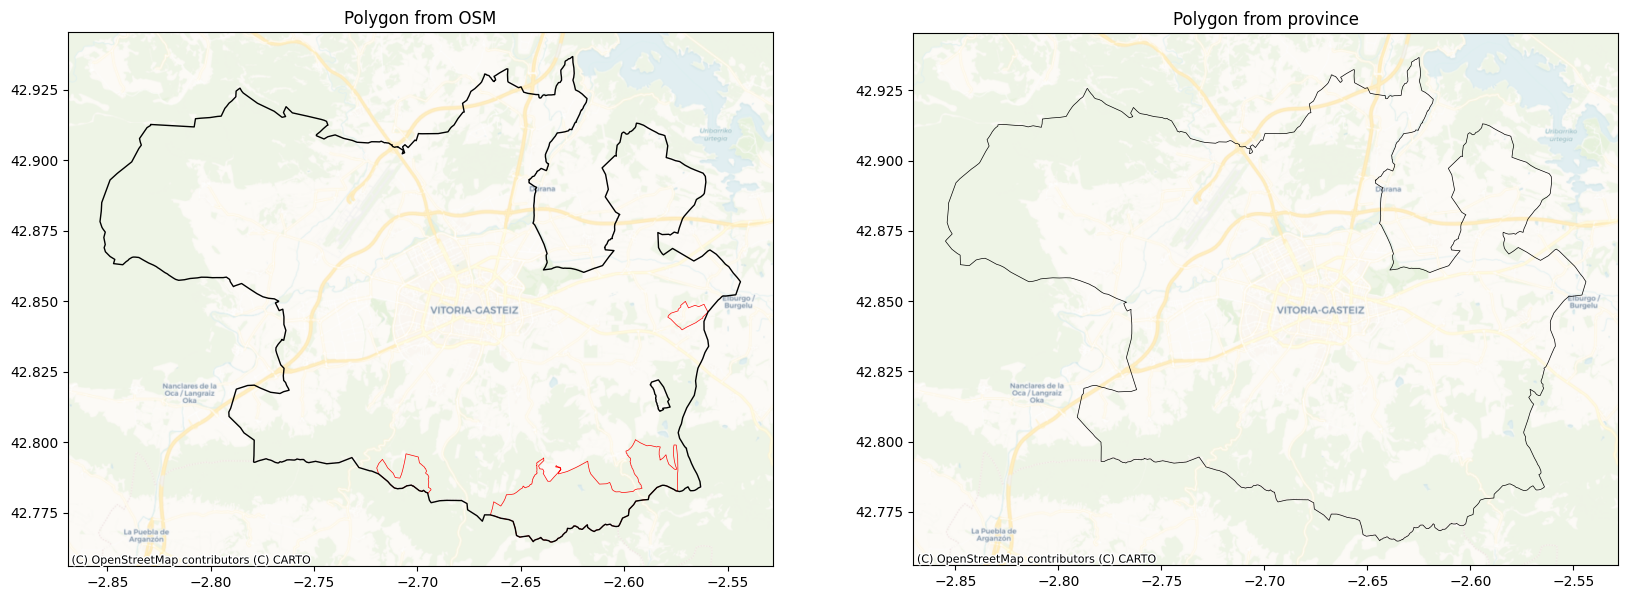

In [11]:
fig, axes = plt.subplots(
    figsize=(20,10),
    ncols = 2,
    nrows = 1
)

ax = axes.flatten()

clipped_subdivisions.plot(
    ax = ax[0],
    facecolor="none",       
    edgecolor="red",        
    linestyle="-",         
    linewidth=0.5
)
osm.plot(
    ax = ax[0],
    facecolor="none",       
    edgecolor="black",        
    linestyle="-",         
    linewidth=1
)
ax[0].set_title("Polygon from OSM")
cx.add_basemap(ax[0], crs=osm.crs, source=cx.providers.CartoDB.Voyager, alpha = 0.7)

municipio.plot(
    ax = ax[1],
    facecolor="none",       
    edgecolor="black",        
    linestyle="-",         
    linewidth=0.5
)
ax[1].set_title("Polygon from province")
cx.add_basemap(ax[1], crs=municipio.crs, source=cx.providers.CartoDB.Voyager, alpha = 0.7)


plt.show()